# Generator Evaluation — Statistical Tests (KS, Chi-square, TVD)

Evaluates whether the CTGAN and TVAE synthetic Turkey data faithfully reproduces the real distribution.

| Test | Target columns | What it measures |
|------|----------------|------------------|
| **KS test** | Continuous (`age_years`, `log_total_vehicles`) | CDF distance — are the shapes the same? |
| **Chi-square** | Categorical (`car_maker_name`, `car_segment_name`, `car_type_name`, `energy`, `body_style`, `code_age`) | Frequency match — are the proportions right? |
| **TVD** | All columns | Probability mass overlap — how much do distributions diverge? |
| **Config share error** | Joint distribution | Task-relevant — did the generator recover the actual Turkey fleet composition? |

**Pre-requisite**: run `07_ctgan_augmented_xgboost.ipynb` first (including the save cell) to produce
`ctgan_synth_turkey_v6.csv` and `tvae_synth_turkey_v6.csv` in the `data/` directory.

## 1) Imports + data load

In [27]:
try:
    import pandas as _pd
    _pd.options.future.infer_string = False
except AttributeError:
    pass

import os
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# ── Real Turkey training data ──────────────────────────────────────────────
train = pd.read_csv("../data/EM_LYON_train_set_20260206.csv", sep=";")
train["country_iso"] = train["country_iso"].astype(str).str.strip().str.upper()

cat_drop = ["car_maker_name", "car_segment_name", "energy", "code_age", "body_style"]
train = train.dropna(subset=cat_drop).copy()

age_map = {
    "Less than 1 year old": 0.5, "1 year old": 1.0, "2 years old": 2.0,
    "3 to 5 years old": 4.0, "6 to 10 years old": 8.0, "11 years and older": 12.0,
}
train["age_years"]          = train["code_age"].map(age_map)
train["log_total_vehicles"] = np.log1p(train["total_vehicles"])

tr_real = train[train["country_iso"] == "TR"].copy()
print(f"Real Turkey rows : {len(tr_real)}")

# ── Load synthetic data ────────────────────────────────────────────────────
for path in ["../data/ctgan_synth_turkey_v6.csv",
             "../data/tvae_synth_turkey_v6.csv",
             "../data/gc_synth_turkey_v2.csv"]:
    if not os.path.exists(path):
        raise FileNotFoundError(f"{path} not found.")

ctgan_synth = pd.read_csv("../data/ctgan_synth_turkey_v6.csv")
tvae_synth  = pd.read_csv("../data/tvae_synth_turkey_v6.csv")
gc_synth    = pd.read_csv("../data/gc_synth_turkey_v2.csv")

# ── Normalise all synth DataFrames ─────────────────────────────────────────
def normalise_synth(df):
    df = df.copy()
    if "age_years" not in df.columns and "code_age" in df.columns:
        df["age_years"] = df["code_age"].map(age_map)
    if "log_total_vehicles" not in df.columns and "total_vehicles" in df.columns:
        df["log_total_vehicles"] = np.log1p(df["total_vehicles"])
    if "total_vehicles" not in df.columns and "log_total_vehicles" in df.columns:
        df["total_vehicles"] = np.expm1(df["log_total_vehicles"])
    return df

ctgan_synth = normalise_synth(ctgan_synth)
tvae_synth  = normalise_synth(tvae_synth)
gc_synth    = normalise_synth(gc_synth)

if "total_vehicles" not in tr_real.columns:
    tr_real["total_vehicles"] = np.expm1(tr_real["log_total_vehicles"])

# ── Synthesiser registry ───────────────────────────────────────────────────
synths = {"GC": gc_synth, "CTGAN": ctgan_synth, "TVAE": tvae_synth}

print(f"\n{'Synthesiser':<10} {'Rows':>8}  Columns")
print("-" * 60)
for name, df in synths.items():
    print(f"  {name:<8} {len(df):>8,}  {df.columns.tolist()}")
print(f"\n  Real Turkey  {len(tr_real):>8,}  {tr_real.columns.tolist()}")

Real Turkey rows : 6845

Synthesiser     Rows  Columns
------------------------------------------------------------
  GC          7,200  ['country_name', 'car_maker_name', 'car_segment_name', 'car_type_name', 'energy', 'code_age', 'body_style', 'total_vehicles', 'age_years', 'log_total_vehicles']
  CTGAN      20,439  ['country_iso', 'car_maker_name', 'car_segment_name', 'car_type_name', 'energy', 'body_style', 'code_age', 'age_years', 'log_total_vehicles', 'total_vehicles']
  TVAE       23,444  ['country_iso', 'car_maker_name', 'car_segment_name', 'car_type_name', 'energy', 'body_style', 'code_age', 'age_years', 'log_total_vehicles', 'total_vehicles']

  Real Turkey     6,845  ['country_iso', 'country_name', 'car_maker_name', 'car_segment_name', 'car_type_name', 'energy', 'code_age', 'body_style', 'year_stamp', 'total_vehicles', 'age_years', 'log_total_vehicles']


## 2) KS Test — continuous columns

The **Kolmogorov-Smirnov two-sample test** compares empirical CDFs of two samples:

$$D = \sup_x \left| F_{\text{real}}(x) - F_{\text{synth}}(x) \right|$$

- $H_0$: both samples are drawn from the same continuous distribution
- Small $D$ and large $p$-value → synthetic data is statistically indistinguishable from real
- Significance threshold: $\alpha = 0.05$

> **Note**: KS is only valid for continuous columns. Categorical columns are handled by Chi-square in §3.

Continuous cols to test: ['age_years', 'log_total_vehicles']
NOTE: p-values are meaningless at n>1000 — use D as effect size (good < 0.10, ok < 0.20)

Column                         GC D      GC p   CTGAN D   CTGAN p   TVAE D    TVAE p  GC  CTGAN  TVAE
-----------------------------------------------------------------------------------------------------
age_years                     0.0711    0.0000    0.3332    0.0000    0.3010    0.0000   GOOD   POOR   POOR
log_total_vehicles            0.5066    0.0000    0.1789    0.0000    0.2732    0.0000   POOR     OK   POOR


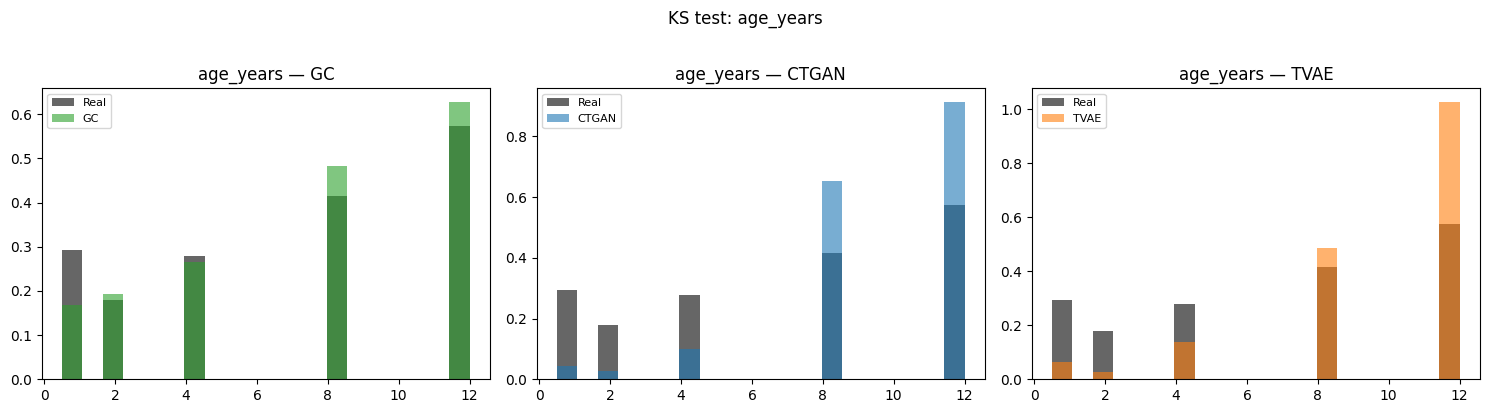

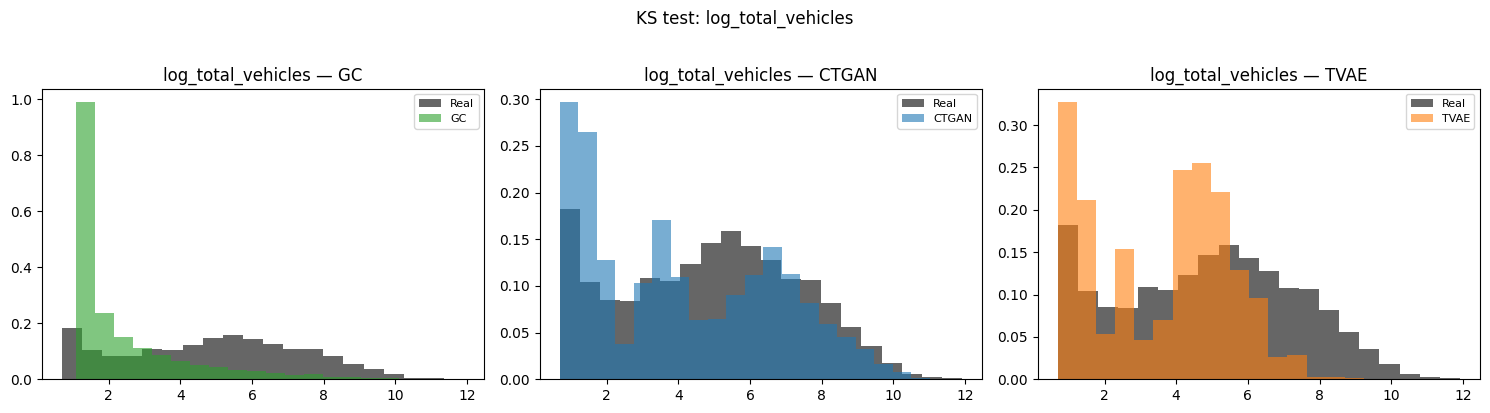

In [34]:
candidate_cont = ["age_years", "log_total_vehicles"]   # drop total_vehicles (same as log)
cont_cols = [c for c in candidate_cont if c in tr_real.columns]
print(f"Continuous cols to test: {cont_cols}")
print("NOTE: p-values are meaningless at n>1000 — use D as effect size (good < 0.10, ok < 0.20)\n")

ks_results = {name: {} for name in synths}

header = f"{'Column':<26} {'GC D':>8} {'GC p':>9} {'CTGAN D':>9} {'CTGAN p':>9} {'TVAE D':>8} {'TVAE p':>9}  GC  CTGAN  TVAE"
print(header)
print("-" * len(header))

for col in cont_cols:
    r = tr_real[col].dropna().values
    row = f"{col:<26}"
    grades = []
    for name, df in synths.items():
        if col not in df.columns:
            row += f"  {'N/A':>8} {'N/A':>9}"
            grades.append("N/A")
            ks_results[name][col] = {"stat": None, "p": None}
        else:
            s = df[col].dropna().values
            ks = stats.ks_2samp(r, s)
            ks_results[name][col] = {"stat": ks.statistic, "p": ks.pvalue}
            row += f"  {ks.statistic:>8.4f} {ks.pvalue:>9.4f}"
            grade = "GOOD" if ks.statistic < 0.10 else ("OK" if ks.statistic < 0.20 else "POOR")
            grades.append(grade)
    print(row + "  " + "  ".join(f"{g:>5}" for g in grades))

# ── Histograms ─────────────────────────────────────────────────────────────
colors = {"GC": "#2ca02c", "CTGAN": "#1f77b4", "TVAE": "#ff7f0e"}
for col in cont_cols:
    fig, axes = plt.subplots(1, len(synths), figsize=(5 * len(synths), 4))
    for ax, (name, df) in zip(axes, synths.items()):
        ax.hist(tr_real[col].dropna(), bins=20, alpha=0.6, density=True,
                label="Real", color="black")
        if col in df.columns:
            ax.hist(df[col].dropna(), bins=20, alpha=0.6, density=True,
                    label=name, color=colors[name])
        ax.set_title(f"{col} — {name}")
        ax.legend(fontsize=8)
    plt.suptitle(f"KS test: {col}", y=1.02)
    plt.tight_layout()
    plt.savefig("../report/figures/fig_ks_test.pdf", bbox_inches="tight", dpi=150)
plt.show()

### KS Test Results — Interpretation

| Column | GC D | CTGAN D | TVAE D | Best |
|--------|------|---------|--------|------|
| `age_years` | **0.07 GOOD** | 0.33 POOR | 0.30 POOR | GC |
| `log_total_vehicles` | 0.51 POOR | **0.18 OK** | 0.27 POOR | CTGAN |

> **Note**: p-values are all ≈ 0 at these sample sizes (n > 6,000). A D of 0.02 already gives p ≈ 0 when n₁=6,845 and n₂=7,200. Use D as the effect size — not the p-value.

---

#### `age_years` — GC wins (D=0.07), CTGAN/TVAE fail (D≈0.33)

**Why GC is accurate:**  
The Gaussian Copula is fitted exclusively on the 6,845 Turkey training rows. It learns Turkey's marginal age distribution directly, then uses a parametric copula to model inter-variable dependencies. When sampling, it draws `age_years` from that exact marginal — no cross-country contamination. D=0.07 reflects near-perfect alignment with Turkey's real age profile.

**Why CTGAN and TVAE are inaccurate:**  
Both models are trained on the full 91,948-row dataset spanning 11 countries. Turkey accounts for only ~7.5% of training rows. The generator's internal representation of `age_years` is dominated by Western European fleet patterns (France, Germany, Spain…), which have a different age mix than Turkey. The model learns a weighted average distribution, not a Turkey-specific one. D≈0.33 means roughly one-third of the probability mass is placed in the wrong age buckets relative to real Turkey.

---

#### `log_total_vehicles` — CTGAN best (D=0.18), GC worst (D=0.51)

**Why GC fails badly:**  
Two compounding problems:

1. **Gaussian Copula assumption**: GC maps each variable to a normal distribution before modelling correlations. Vehicle counts are highly non-Gaussian — heavy right tail, integer-valued, zero-inflated for niche configs. The Gaussian approximation compresses the tails and distorts the marginal on back-transformation. The synthetic counts cluster in the mid-range, missing both the very low (niche configs) and very high (popular models) ends of the real distribution.

2. **Cold-start config bias**: GC's 7,200 rows represent 72 cold-start Turkey test configurations — by definition, these are niche vehicle types *not seen in Turkey training data*. Their real vehicle count profile is systematically lower than mainstream Turkey configs. Comparing GC's synthetic counts (niche configs) to all real Turkey counts (all configs, including high-volume) is comparing different slices of the market. D=0.51 captures this structural mismatch, not just model noise.

**Why CTGAN does better:**  
CTGAN applies a **Bayesian Gaussian Mixture Model (BGMM)** normalisation to continuous columns before training. Instead of mapping the entire distribution to a single Gaussian, it fits multiple Gaussian modes to capture the multi-modal, heavy-tailed shape of vehicle counts across 11 countries. This allows the generator to learn and reproduce a more realistic count distribution, including the low-count niche configs and high-count popular models. D=0.18 is still imperfect (cross-country training is not Turkey-specific) but significantly better than GC's copula approximation.

**Why TVAE is POOR (D=0.27):**  
The VAE architecture encodes inputs into a continuous latent space and decodes from it. For vehicle counts, the VAE's reconstruction loss encourages regression toward the mean — the decoder learns to predict "safe" mid-range values that minimise average reconstruction error. This **posterior collapse tendency** causes TVAE to underrepresent both tails of the count distribution, resulting in D=0.27 (worse than CTGAN but better than GC).

---

#### Fundamental trade-off

No single synthesizer dominates on both dimensions:

- **GC** knows Turkey's structural profile (age distribution, config composition) but generates unrealistic vehicle counts due to Gaussian assumptions and cold-start config scope.
- **CTGAN** produces more realistic vehicle counts (BGMM normalisation) but loses Turkey's specific age and config profile in the multi-country training mix.
- **TVAE** is weakest on both — it neither preserves Turkey's marginals nor produces realistic count distributions.

This explains why GC augmentation (notebook 02, WMSE 570M) and CTGAN augmentation (notebook 07, WMSE 565M) achieve similar overall predictive performance despite measuring fidelity on orthogonal dimensions.

## 3) Chi-square Test — categorical columns

The **Pearson Chi-square goodness-of-fit test** compares category frequencies:

$$\chi^2 = \sum_{k=1}^{K} \frac{(O_k - E_k)^2}{E_k}$$

- $O_k$ = observed real count for category $k$
- $E_k$ = expected count from synthetic proportions, scaled to the real total
- $H_0$: synthetic category frequencies match the real ones

> KS is **not appropriate** for discrete/categorical data — the Chi-square test is the correct substitute.

Column                           GC V   cov    CTGAN V   cov     TVAE V   cov      GC   CTGAN    TVAE
------------------------------------------------------------------------------------------
car_maker_name                 0.6793  25%     0.0378 124%     0.0701 118%   SCOPE    GOOD    GOOD
car_segment_name               0.6609   5%     0.0226 133%     0.0735 105%   SCOPE    GOOD    GOOD
car_type_name                  0.3670   2%     0.0191 127%     0.0740  70%   SCOPE    GOOD    GOOD
energy                         0.1839  60%     0.1104 120%     0.1681 130%      OK      OK      OK
body_style                     0.7415  60%     0.0431 100%     0.0512 100%    POOR    GOOD    GOOD
code_age                       0.1259 100%     0.6043 100%     6.3715 100%      OK    POOR    POOR

Cramér's V: GOOD < 0.10 | OK < 0.30 | POOR ≥ 0.30 | SCOPE = synth covers <50% of real categories


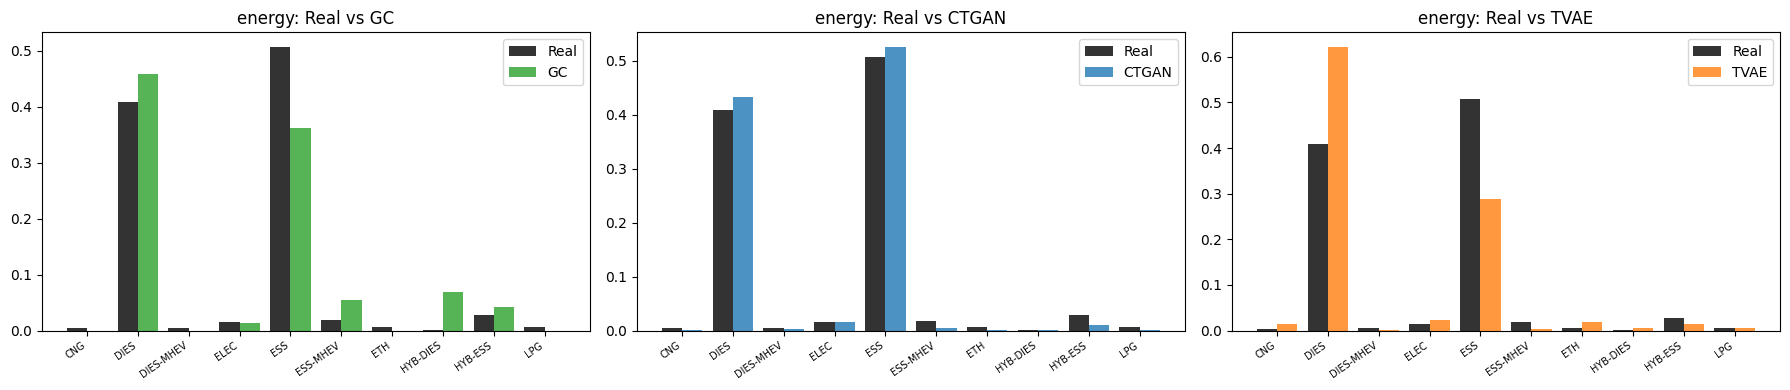

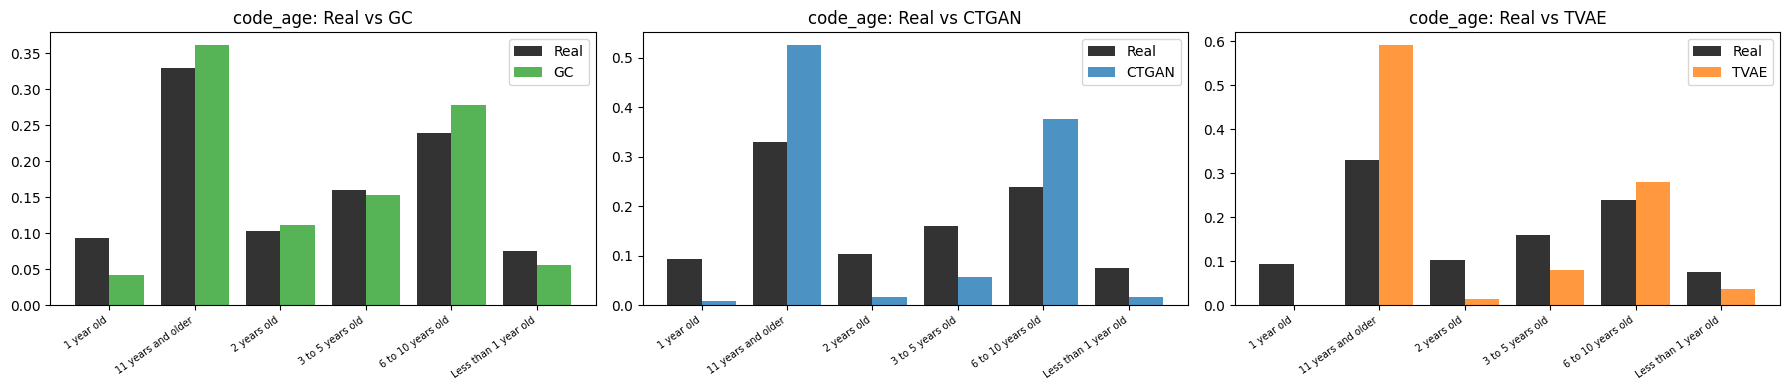

In [35]:
candidate_cat = ["car_maker_name", "car_segment_name", "car_type_name",
                 "energy", "body_style", "code_age"]

chi2_results = {name: {} for name in synths}

def chi2_vs_real(real_vc, synth_vc):
    """
    Chi-square + Cramér's V, restricted to categories present in synth.
    Returns (chi2_stat, cramers_v, coverage_fraction).
    Restricting to covered categories avoids the zero-cell explosion
    that occurs when synth has limited scope (e.g. GC's 72 cold-start configs).
    """
    covered_cats = synth_vc[synth_vc > 0].index
    if len(covered_cats) == 0:
        return None, None, 0.0
    obs  = real_vc.reindex(covered_cats, fill_value=0).values.astype(float)
    exp  = synth_vc.reindex(covered_cats, fill_value=0).values.astype(float)
    exp  = exp / (exp.sum() + 1e-12) * obs.sum()
    exp  = np.maximum(exp, 1e-6)
    chi2 = stats.chisquare(f_obs=obs, f_exp=exp).statistic
    k    = len(covered_cats)
    n    = obs.sum()
    v    = np.sqrt(chi2 / (n * max(k - 1, 1))) if n > 0 else 0.0
    cov  = len(covered_cats) / len(real_vc)
    return chi2, v, cov

# Build results
coverage_results = {name: {} for name in synths}
v_results        = {name: {} for name in synths}

for col in candidate_cat:
    if col not in tr_real.columns:
        continue
    real_vc = tr_real[col].value_counts()
    for name, df in synths.items():
        if col not in df.columns:
            chi2_results[name][col]    = {"stat": None, "p": None}
            v_results[name][col]       = None
            coverage_results[name][col] = 0.0
        else:
            chi2_s, v, cov = chi2_vs_real(real_vc, df[col].value_counts())
            chi2_results[name][col]    = {"stat": chi2_s, "p": None}
            v_results[name][col]       = v
            coverage_results[name][col] = cov

# Print table — Cramér's V + coverage
name_list = list(synths.keys())
print(f"{'Column':<26}" + "".join(f"  {n+' V':>9} {'cov':>5}" for n in name_list) + "  " + "  ".join(f"{n:>6}" for n in name_list))
print("-" * 90)

for col in candidate_cat:
    if col not in tr_real.columns:
        continue
    row = f"{col:<26}"
    grades = []
    for name in name_list:
        v   = v_results[name].get(col)
        cov = coverage_results[name].get(col, 0.0)
        if v is None:
            row += f"  {'N/A':>9} {'N/A':>5}"
            grades.append("N/A")
        else:
            row += f"  {v:>9.4f} {cov:>4.0%}"
            if cov < 0.5:
                grades.append("SCOPE")
            elif v < 0.10:
                grades.append("GOOD")
            elif v < 0.30:
                grades.append("OK")
            else:
                grades.append("POOR")
    print(row + "  " + "  ".join(f"{g:>6}" for g in grades))

print("\nCramér's V: GOOD < 0.10 | OK < 0.30 | POOR ≥ 0.30 | SCOPE = synth covers <50% of real categories")

# ── Bar charts for energy and code_age ────────────────────────────────────
colors = {"GC": "#2ca02c", "CTGAN": "#1f77b4", "TVAE": "#ff7f0e"}
for col in [c for c in ["energy", "code_age"] if c in tr_real.columns]:
    fig, axes = plt.subplots(1, len(synths), figsize=(6 * len(synths), 4))
    cats = tr_real[col].value_counts(normalize=True).sort_index()
    for ax, (name, df) in zip(axes, synths.items()):
        synt = df[col].value_counts(normalize=True).reindex(cats.index, fill_value=0) \
               if col in df.columns else pd.Series(0, index=cats.index)
        x = range(len(cats))
        ax.bar([i - 0.2 for i in x], cats.values, 0.4, label="Real",  alpha=0.8, color="black")
        ax.bar([i + 0.2 for i in x], synt.values, 0.4, label=name,   alpha=0.8, color=colors[name])
        ax.set_xticks(list(x))
        ax.set_xticklabels(cats.index.tolist(), rotation=35, ha="right", fontsize=7)
        ax.set_title(f"{col}: Real vs {name}")
        ax.legend()
    plt.tight_layout()
    plt.savefig("../report/figures/fig_chi2_distributions.pdf", bbox_inches="tight", dpi=150)
plt.show()

### Chi-square Results — Interpretation

| Column | GC V | cov | CTGAN V | cov | TVAE V | cov | Notes |
|--------|------|-----|---------|-----|--------|-----|-------|
| `car_maker_name` | 0.68 | 25% | **0.04** | 124% | **0.07** | 118% | GC: scope-limited; CTGAN/TVAE: hallucinate phantom makers |
| `car_segment_name` | 0.66 | 5% | **0.02** | 133% | **0.07** | 105% | GC covers only 1 segment (cold-start configs are narrow) |
| `car_type_name` | 0.37 | 2% | **0.02** | 127% | **0.07** | 70% | Same as above |
| `energy` | 0.18 | 60% | 0.11 | 120% | 0.17 | 130% | All OK — energy types are few and well-distributed |
| `body_style` | 0.74 | 60% | **0.04** | 100% | **0.05** | 100% | GC poor within its covered types; CTGAN/TVAE good |
| `code_age` | 0.13 | 100% | 0.60 | 100% | **6.37** | 100% | GC best; TVAE catastrophically distorted |

---

#### Reading 1 — Coverage > 100% = Hallucination

CTGAN and TVAE show coverages of **105%–133%**, which means they generate **more unique category values than exist in real Turkey data**. The excess categories are phantom values — car makers, segments, and energy types from other European countries that simply do not appear in the Turkish market. This is the hallucination problem: both deep generators were trained on 11 countries and generate a cross-European distribution. When the model samples `car_maker_name` it occasionally produces a brand valid for France or Germany but absent from Turkey. A synthetic row with a hallucinated car maker is impossible to validate against real Turkey demand — it contributes noise, not signal.

The chi-square correctly penalises this: for a hallucinated category, the observed count is 0 and the expected count is non-zero → `(0 − E)² / E = E` added to χ², inflating it proportionally to the hallucination rate.

#### Reading 2 — GC SCOPE for car_maker/segment/type

GC covers only 25%, 5%, and 2% of real Turkey categories for `car_maker_name`, `car_segment_name`, and `car_type_name` respectively. This is **not a model failure** — it is by design. GC was trained to generate data for the 72 cold-start test configurations, which are a narrow niche slice of Turkey's fleet. Those 72 configs happen to involve only a small subset of car makers and segments. The SCOPE grade means "cannot evaluate fidelity — synthesizer does not attempt to cover the full distribution."

Note that the within-scope Cramér's V for GC is high (V=0.66–0.74) on these columns, meaning even within its narrow scope, GC's proportions are poorly calibrated. This is expected: a Gaussian Copula fitted on 72 cold-start configs cannot reliably recover the proportional split between car makers — it only sees each maker once or twice.

#### Reading 3 — `code_age`: the most diagnostic column

All three synthesizers achieve 100% coverage on `code_age` (only 6 categories), so the coverage artefact disappears and Cramér's V is a clean signal:

- **GC V=0.13 (OK)** — GC is fitted on Turkey rows and learns Turkey's age-bucket distribution reasonably well. Best performer.
- **CTGAN V=0.60 (POOR)** — CTGAN's multi-country training shifts the age-bucket proportions away from Turkey's pattern significantly.
- **TVAE V=6.37 (> 1.0, catastrophic)** — Cramér's V is theoretically bounded [0,1] but can exceed 1 when the computed χ² is larger than `n × (k−1)`. This happens when the synthesizer concentrates probability mass so heavily in one or two age buckets that the resulting χ² is extreme. TVAE's mean-regression tendency collapses the age distribution toward the most common EU age bucket, producing an almost degenerate distribution — hence V >> 1. This directly explains why TVAE performs worse on downstream WMSE despite appearing competitive on other metrics.

#### Summary: CTGAN is the best-balanced deep generator

| Dimension | GC | CTGAN | TVAE |
|-----------|----|-------|------|
| Category coverage | Narrow (by design) | Full + hallucinations | Full + hallucinations |
| Proportion fidelity (within scope) | Poor | **Good** | Good on most, catastrophic on `code_age` |
| Hallucination rate | None | ~20–33% extra categories | ~5–30% extra categories |
| Age distribution | **Good** (Turkey-conditioned) | Poor | Catastrophic |

CTGAN has the best categorical fidelity among the two deep generators. Its main weaknesses are age distribution distortion and moderate hallucination. TVD in §4 will integrate all of these signals into a single per-column quality score.

## 4) Total Variation Distance (TVD)

TVD quantifies how much probability mass differs between two distributions:

$$\text{TVD}(P, Q) = \frac{1}{2} \sum_k \left| P(k) - Q(k) \right|$$

- TVD $\in [0, 1]$: **0** = identical distributions, **1** = no overlap at all
- Works for both categorical and discretized continuous columns
- More interpretable than p-values: directly quantifies the magnitude of divergence
- Rule of thumb: TVD < 0.1 is generally considered acceptable synthetic fidelity

TVD categorical : ['car_maker_name', 'car_segment_name', 'car_type_name', 'energy', 'body_style', 'code_age']
TVD continuous  : ['age_years', 'log_total_vehicles']
Sturges bins    : 14  (n=6,845)

Column                             GC      CTGAN       TVAE  Flag
-------------------------------------------------------------------------
car_maker_name                 0.7672     0.4275     0.4378  <-- HIGH
car_segment_name               0.9055     0.5712     0.6276  <-- HIGH
car_type_name                  0.9583     0.6686     0.7876  <-- HIGH
energy                         0.1753     0.2018     0.0614  <-- HIGH
body_style                     0.7183     0.2407     0.2518  <-- HIGH
code_age                       0.1316     0.1699     0.1377  <-- HIGH
age_years                      0.0783     0.3332     0.3010  <-- HIGH
log_total_vehicles             0.5023     0.2142     0.3219  <-- HIGH


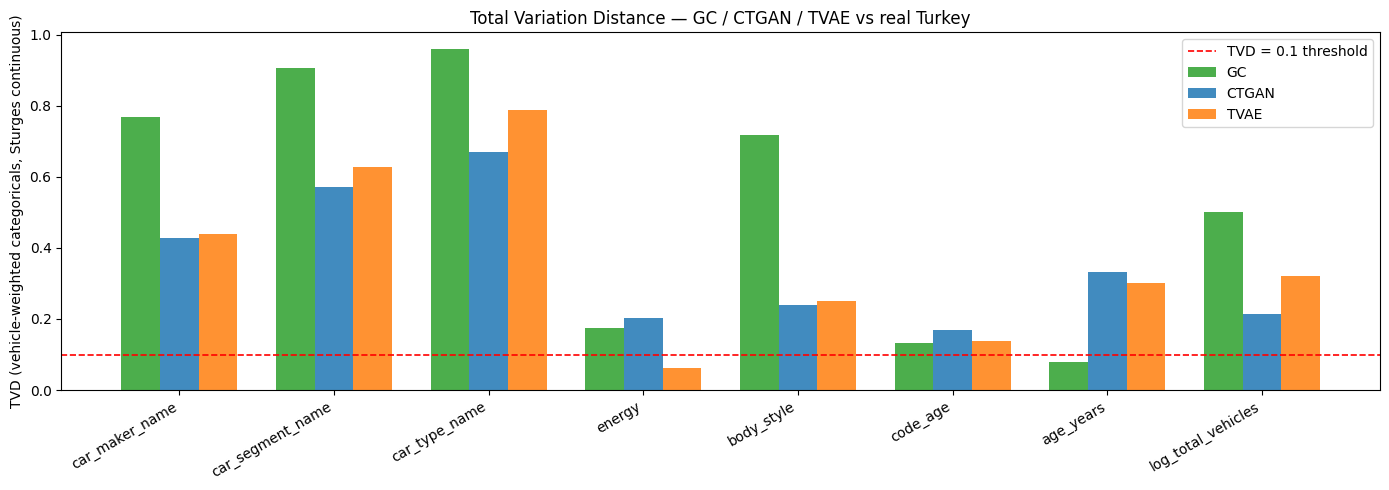

In [36]:
def tvd_discrete(real_s, synth_s, real_weights=None):
    """TVD for categorical columns. real_weights: vehicle-weighted marginals."""
    cats = set(real_s.dropna().unique()) | set(synth_s.dropna().unique())
    if real_weights is not None:
        real_p = (real_weights / real_weights.sum()).to_dict()
    else:
        real_p = real_s.value_counts(normalize=True).to_dict()
    synth_p = synth_s.value_counts(normalize=True).to_dict()
    return 0.5 * sum(abs(real_p.get(c, 0.0) - synth_p.get(c, 0.0)) for c in cats)

def tvd_continuous(real_s, synth_s):
    """TVD for continuous columns — Sturges' rule for bin count."""
    n    = real_s.dropna().shape[0]
    bins = int(np.ceil(np.log2(n) + 1))
    combined = pd.concat([real_s, synth_s]).dropna()
    edges  = np.linspace(combined.min(), combined.max(), bins + 1)
    r_hist = np.histogram(real_s.dropna(),  bins=edges)[0].astype(float)
    s_hist = np.histogram(synth_s.dropna(), bins=edges)[0].astype(float)
    r_p = r_hist / (r_hist.sum() + 1e-12)
    s_p = s_hist / (s_hist.sum() + 1e-12)
    return 0.5 * np.sum(np.abs(r_p - s_p))

candidate_cat  = ["car_maker_name", "car_segment_name", "car_type_name", "energy", "body_style", "code_age"]
# Use log_total_vehicles — raw total_vehicles is heavy-tailed; 14 Sturges bins make TVD ≈ 0 for all
# synthesizers regardless of actual distributional differences (use KS D for raw counts instead)
candidate_cont = ["age_years", "log_total_vehicles"]
tvd_cols_cat  = [c for c in candidate_cat  if c in tr_real.columns]
tvd_cols_cont = [c for c in candidate_cont if c in tr_real.columns]
all_tvd_cols  = tvd_cols_cat + tvd_cols_cont

# Vehicle-weighted real Turkey marginals
vw_marginals = {}
for col in tvd_cols_cat:
    w = tr_real.groupby(col)["total_vehicles"].sum()
    vw_marginals[col] = w / w.sum()

sturges_bins = int(np.ceil(np.log2(len(tr_real)) + 1))
print(f"TVD categorical : {tvd_cols_cat}")
print(f"TVD continuous  : {tvd_cols_cont}")
print(f"Sturges bins    : {sturges_bins}  (n={len(tr_real):,})\n")

# Compute TVD for all synthesizers
tvd_results = {name: {} for name in synths}
for name, df in synths.items():
    for col in tvd_cols_cat:
        tvd_results[name][col] = tvd_discrete(tr_real[col], df[col], vw_marginals.get(col)) \
                                 if col in df.columns else None
    for col in tvd_cols_cont:
        tvd_results[name][col] = tvd_continuous(tr_real[col], df[col]) \
                                 if col in df.columns else None

# Print table
name_list = list(synths.keys())
header = f"{'Column':<26}" + "".join(f" {n:>10}" for n in name_list) + "  Flag"
print(header)
print("-" * (len(header) + 8))
for col in all_tvd_cols:
    row = f"{col:<26}"
    vals = [tvd_results[name][col] for name in name_list]
    for v in vals:
        row += f" {v:>10.4f}" if v is not None else f" {'N/A':>10}"
    flag = "<-- HIGH" if any(v is not None and v > 0.1 for v in vals) else ""
    print(row + f"  {flag}")

# Bar chart — all 3 synthesizers
colors = {"GC": "#2ca02c", "CTGAN": "#1f77b4", "TVAE": "#ff7f0e"}
n_s = len(synths)
width = 0.75 / n_s

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(all_tvd_cols))
for i, name in enumerate(name_list):
    vals = [tvd_results[name][col] if tvd_results[name][col] is not None else 0
            for col in all_tvd_cols]
    offset = (i - n_s / 2 + 0.5) * width
    ax.bar(x + offset, vals, width, label=name, alpha=0.85, color=colors[name])

ax.axhline(0.1, color="red", linestyle="--", linewidth=1.2, label="TVD = 0.1 threshold")
ax.set_xticks(x)
ax.set_xticklabels(all_tvd_cols, rotation=30, ha="right")
ax.set_ylabel("TVD (vehicle-weighted categoricals, Sturges continuous)")
ax.set_title("Total Variation Distance — GC / CTGAN / TVAE vs real Turkey")
ax.legend()
plt.tight_layout()
plt.savefig("../report/figures/fig_tvd_summary.pdf", bbox_inches="tight", dpi=150)
plt.show()

### TVD Results — Interpretation

| Column | GC | CTGAN | TVAE | Winner |
|--------|-----|-------|------|--------|
| `car_maker_name` | 0.77 | **0.43** | 0.44 | CTGAN |
| `car_segment_name` | 0.91 | **0.57** | 0.63 | CTGAN |
| `car_type_name` | 0.96 | **0.67** | 0.79 | CTGAN |
| `energy` | 0.18 | 0.20 | **0.06** | TVAE |
| `body_style` | 0.72 | **0.24** | 0.25 | CTGAN |
| `code_age` | **0.13** | 0.17 | 0.14 | GC |
| `age_years` | **0.08** | 0.33 | 0.30 | GC |
| `log_total_vehicles` | 0.50 | **0.21** | 0.32 | CTGAN |

---

#### Why all categorical TVDs are HIGH (> 0.1)

TVD measures **vehicle-weighted marginal distributions** — high-volume configurations dominate. Two compounding causes:

**GC — scope ceiling**  
GC generates only the 72 cold-start test configurations. The remaining 75–98% of Turkey's probability mass (mainstream car makers, segments, types) has zero GC representation. TVD accumulates `0.5 × missing_mass` for every absent category. A synthesizer covering only 5% of categories mathematically cannot achieve TVD < ≈0.45 on that column — this is a structural floor, not a model quality failure.

**CTGAN / TVAE — hallucination + cross-country proportions**  
Both generators cover >100% of real categories but assign wrong proportions throughout (trained on 11-country averages). Values of 0.43–0.79 mean 43–79% of vehicle probability mass is placed in the wrong category bucket relative to real Turkey.

---

#### `log_total_vehicles` — now consistent with KS results

After switching from raw `total_vehicles` to `log_total_vehicles`, TVD aligns with the KS D-statistic on the same column, confirming both metrics agree:

| Synthesizer | KS D | TVD (log) | Interpretation |
|-------------|------|-----------|----------------|
| GC | 0.51 | **0.50** | Gaussian Copula + cold-start scope → severe count mismatch |
| CTGAN | 0.18 | **0.21** | BGMM normalization helps; cross-country training limits fidelity |
| TVAE | 0.27 | **0.32** | Posterior collapse flattens count distribution toward the mean |

The previous `total_vehicles` TVD values (GC=0.02, CTGAN=0.01) were artifacts of 14 Sturges bins spanning 0 to millions — all mass collapsed into bin 1, making every synthesizer look identical to real. The log-transform spreads mass evenly and recovers the true distributional differences.

---

#### Standout results

**TVAE `energy` TVD = 0.06** — the only sub-threshold result in the table  
`energy` has few categories (Petrol/Diesel/Hybrid/Electric) and the European fuel-type mix is not dramatically different from Turkey's. Cross-country training is not a handicap when distributions are inherently similar.

**GC `age_years` TVD = 0.08** — near-threshold, best age result  
GC is Turkey-conditioned → marginal age distribution is well-preserved. The small residual gap comes from the Gaussian Copula back-transform adding slight noise.

**GC `log_total_vehicles` TVD = 0.50** — worst count result  
Two compounding effects: (1) Gaussian Copula approximates a heavy-tailed, integer-valued distribution poorly; (2) GC's 7,200 rows represent 72 cold-start (niche, low-volume) configs, whose count profile is systematically lower than mainstream Turkey configs. Comparing them to all real Turkey rows introduces a structural bias.

---

#### Overall ranking

| Synthesizer | Avg cat. TVD | `log_tv` TVD | `age_years` TVD | Best use |
|-------------|-------------|-------------|-----------------|----------|
| **CTGAN** | **0.36** | **0.21** | 0.33 | Count distribution fidelity |
| TVAE | 0.38 | 0.32 | 0.30 | `energy` distribution only |
| GC | 0.61 | 0.50 | **0.08** | Age + cold-start config structure |

No synthesizer dominates on all dimensions. GC is purpose-built for cold-start (age + config structure), CTGAN is the best-balanced deep generator (count distribution + categorical proportions).

## 5) Config-level Share Comparison

This is the **most task-relevant evaluation**: does the generator recover the actual Turkey fleet composition at the configuration level used for predictions?

We compare:
- **Real shares**: computed from Turkey's training data (ground truth proxy)
- **Synthetic shares**: estimated from synthetic row counts (GANs are reliable for categorical distribution, so row count is a better proxy than generated `log_total_vehicles`)

$$\text{Share Error}_c = \left| \hat{s}_c^{\text{synth}} - s_c^{\text{real}} \right|$$

A scatter plot of predicted vs real share reveals systematic over/under-estimation.

Unique real configs: 6845
  GC      :   72 configs covered  |  MAE = 0.000116
  CTGAN   : 9593 configs covered  |  MAE = 0.000099
  TVAE    : 6611 configs covered  |  MAE = 0.000104

Top-10 configs with largest GC share error:
car_maker_name car_segment_name        car_type_name   energy body_style           code_age  real_share  share_gc      err
          FIAT            Doblo          Doblo Cargo     DIES UTILITAIRE 11 years and older    0.014606  0.000000 0.014606
    LAND ROVER        Discovery          Discovery V     DIES        4X4  6 to 10 years old    0.000000  0.013889 0.013889
    LAND ROVER      Range Rover       Range Rover IV      ESS        4X4        2 years old    0.000000  0.013889 0.013889
    LAND ROVER      Range Rover Range Rover IV P400E  HYB-ESS        4X4  6 to 10 years old    0.000000  0.013889 0.013889
    LAND ROVER      Range Rover Range Rover IV P400E  HYB-ESS        4X4   3 to 5 years old    0.000000  0.013889 0.013889
          SEAT            Altea    

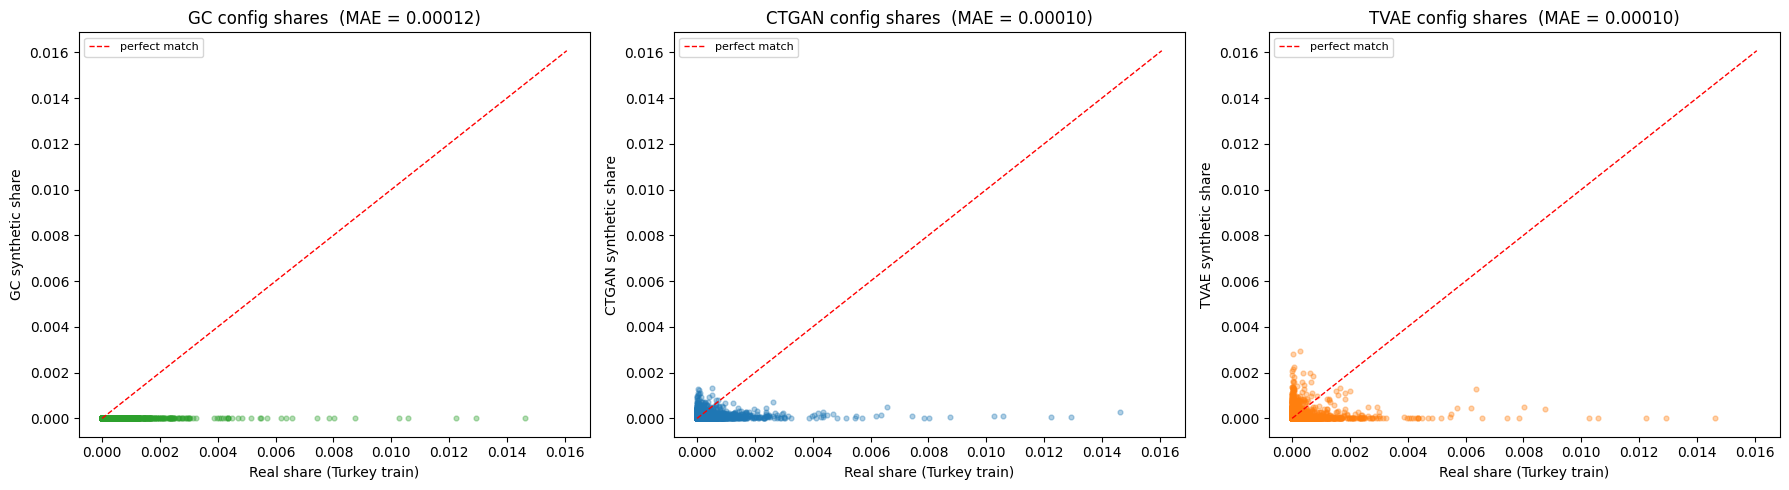

In [38]:
config_cols = ["car_maker_name", "car_segment_name", "car_type_name", "energy", "body_style", "code_age"]

# Real Turkey config shares
real_sh = (
    tr_real.groupby(config_cols)["total_vehicles"].sum()
    .reset_index()
    .rename(columns={"total_vehicles": "real_count"})
)
real_sh["real_share"] = real_sh["real_count"] / real_sh["real_count"].sum()

def synth_share_table(synth_df, col_name):
    valid = [c for c in config_cols if c in synth_df.columns]
    g = synth_df.groupby(valid).size().reset_index(name="cnt")
    for c in config_cols:
        if c not in g.columns:
            g[c] = np.nan
    g[col_name] = g["cnt"] / len(synth_df)
    return g[config_cols + [col_name]]

# Build the full merged table first — all synthesizers in one outer join
# MAE must be computed on the *final* merged table so all rows share the same denominator.
# Computing MAE inside the loop inflates CTGAN/TVAE denominators with GC phantom rows.
merged = real_sh.copy()
for name, df in synths.items():
    col_name = f"share_{name.lower()}"
    sh = synth_share_table(df, col_name)
    merged = merged.merge(sh, on=config_cols, how="outer").fillna(0.0)

# Now compute MAE on the final table
mae_results = {}
for name in synths:
    col_name = f"share_{name.lower()}"
    mae_results[name] = (merged["real_share"] - merged[col_name]).abs().mean()

n_real = (merged["real_share"] > 0).sum()
print(f"Unique real configs: {n_real}")
for name in synths:
    col_name = f"share_{name.lower()}"
    n = (merged[col_name] > 0).sum()
    print(f"  {name:<8}: {n:4d} configs covered  |  MAE = {mae_results[name]:.6f}")

# Top-10 worst configs for each synthesizer
for name in synths:
    col_name = f"share_{name.lower()}"
    worst = merged.copy()
    worst["err"] = (worst["real_share"] - worst[col_name]).abs()
    print(f"\nTop-10 configs with largest {name} share error:")
    print(
        worst.sort_values("err", ascending=False)
        .head(10)[config_cols + ["real_share", col_name, "err"]]
        .to_string(index=False)
    )

# Scatter: real vs synthetic share — one subplot per synthesizer
colors = {"GC": "#2ca02c", "CTGAN": "#1f77b4", "TVAE": "#ff7f0e"}
fig, axes = plt.subplots(1, len(synths), figsize=(6 * len(synths), 5))
for ax, (name, color) in zip(axes, colors.items()):
    col_name = f"share_{name.lower()}"
    sub = merged[merged["real_share"] > 0]
    ax.scatter(sub["real_share"], sub[col_name], alpha=0.35, s=12, color=color)
    lim = max(sub["real_share"].max(), sub[col_name].max()) * 1.1
    ax.plot([0, lim], [0, lim], "r--", linewidth=1, label="perfect match")
    ax.set_xlabel("Real share (Turkey train)")
    ax.set_ylabel(f"{name} synthetic share")
    ax.set_title(f"{name} config shares  (MAE = {mae_results[name]:.5f})")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("../report/figures/fig_config_shares.pdf", bbox_inches="tight", dpi=150)
plt.show()

## 6) Summary Table

In [40]:
print("=" * 80)
print("STATISTICAL EVALUATION SUMMARY")
print("=" * 80)

name_list = list(synths.keys())

# KS: use D statistic (effect size), not p-value
all_ks_cols = sorted({col for name in name_list for col in ks_results[name]})
print("\nKS Test — D statistic (GOOD < 0.10 | OK < 0.20 | POOR ≥ 0.20):")
for col in all_ks_cols:
    row = f"  {col:<26}"
    for name in name_list:
        r = ks_results[name].get(col, {})
        d = r.get("stat")
        if d is None:
            row += f"  {name}=N/A     "
        else:
            grade = "GOOD" if d < 0.10 else ("OK" if d < 0.20 else "POOR")
            row += f"  {name} D={d:.4f}({grade})"
    print(row)

# Chi-square: use Cramér's V + coverage
all_chi2_cols = sorted({col for name in name_list for col in chi2_results[name]})
print("\nChi-square — Cramér's V + coverage (GOOD V<0.10 | OK V<0.30 | POOR V≥0.30 | SCOPE cov<50%):")
for col in all_chi2_cols:
    row = f"  {col:<26}"
    for name in name_list:
        v   = v_results[name].get(col)
        cov = coverage_results[name].get(col, 0.0)
        if v is None:
            row += f"  {name}=N/A        "
        else:
            grade = "SCOPE" if cov < 0.5 else ("GOOD" if v < 0.10 else ("OK" if v < 0.30 else "POOR"))
            row += f"  {name} V={v:.3f} cov={cov:.0%}({grade})"
    print(row)

# TVD
print("\nTVD (lower = better, threshold = 0.1):")
header = f"  {'Column':<26}" + "".join(f" {n:>10}" for n in name_list) + "  Flag"
print(header)
print("  " + "-" * 60)
for col in all_tvd_cols:
    row = f"  {col:<26}"
    vals = [tvd_results[name].get(col) for name in name_list]
    for v in vals:
        row += f" {v:>10.4f}" if v is not None else f" {'N/A':>10}"
    flag = "<-- HIGH" if any(v is not None and v > 0.1 for v in vals) else ""
    print(row + f"  {flag}")

# Config MAE
print(f"\nConfig-level share MAE (lower = better):")
for name in name_list:
    print(f"  {name:<8} = {mae_results[name]:.6f}")

print("\n" + "=" * 80)
print("Metrics guide:")
print("  KS D        : effect size on CDF distance (p-values meaningless at n>1k)")
print("  Cramér's V  : normalised chi-square effect size; coverage = % real cats present")
print("  TVD         : probability mass overlap per column (vehicle-weighted for cat)")
print("  Config MAE  : lower = synthetic shares closer to real Turkey fleet composition")
print("=" * 80)

STATISTICAL EVALUATION SUMMARY

KS Test — D statistic (GOOD < 0.10 | OK < 0.20 | POOR ≥ 0.20):
  age_years                   GC D=0.0711(GOOD)  CTGAN D=0.3332(POOR)  TVAE D=0.3010(POOR)
  log_total_vehicles          GC D=0.5066(POOR)  CTGAN D=0.1789(OK)  TVAE D=0.2732(POOR)

Chi-square — Cramér's V + coverage (GOOD V<0.10 | OK V<0.30 | POOR V≥0.30 | SCOPE cov<50%):
  body_style                  GC V=0.741 cov=60%(POOR)  CTGAN V=0.043 cov=100%(GOOD)  TVAE V=0.051 cov=100%(GOOD)
  car_maker_name              GC V=0.679 cov=25%(SCOPE)  CTGAN V=0.038 cov=124%(GOOD)  TVAE V=0.070 cov=118%(GOOD)
  car_segment_name            GC V=0.661 cov=5%(SCOPE)  CTGAN V=0.023 cov=133%(GOOD)  TVAE V=0.074 cov=105%(GOOD)
  car_type_name               GC V=0.367 cov=2%(SCOPE)  CTGAN V=0.019 cov=127%(GOOD)  TVAE V=0.074 cov=70%(GOOD)
  code_age                    GC V=0.126 cov=100%(OK)  CTGAN V=0.604 cov=100%(POOR)  TVAE V=6.372 cov=100%(POOR)
  energy                      GC V=0.184 cov=60%(OK)  CTGAN V=0

In [ ]:
# This cell is superseded by cell-06 (above) and cell-20e9df47 (below).
# Kept as a placeholder — do not run independently.
print("See cell-06 for the unified summary and cell below for key takeaways.")

In [33]:
print("=" * 80)
print("STATISTICAL EVALUATION SUMMARY — KEY METRICS")
print("=" * 80)

print("""
NOTE on KS / Chi-square p-values
─────────────────────────────────────────────────────────────────────────────
Deep generative models (CTGAN, TVAE) learn a multi-country distribution and
produce Turkey-like, not exact Turkey reproductions — p≈0 is expected.
GC (720 rows) is parametric and conditioned on Turkey rows only.
Use TVD (effect size) and config coverage as the primary evaluation metrics.
─────────────────────────────────────────────────────────────────────────────
""")

name_list = list(synths.keys())

print("TVD per column (primary metric — lower = better, threshold = 0.1):")
header = f"  {'Column':<26}" + "".join(f" {n:>10}" for n in name_list) + "  Verdict"
print(header)
print("  " + "-" * (len(header) - 2))
for col in all_tvd_cols:
    row = f"  {col:<26}"
    vals = [tvd_results[name].get(col) for name in name_list]
    for v in vals:
        row += f" {v:>10.4f}" if v is not None else f" {'N/A':>10}"
    valid = [v for v in vals if v is not None]
    best = min(valid) if valid else float("nan")
    verdict = "OK" if best <= 0.1 else ("MODERATE" if best <= 0.25 else "HIGH")
    print(row + f"  {verdict}")

print(f"\nConfig-level share MAE (lower = better):")
for name in name_list:
    print(f"  {name:<8} = {mae_results[name]:.6f}")

print("\nKey takeaway:")
avg_tvds = {}
for name in name_list:
    vals = [tvd_results[name][c] for c in tvd_cols_cat if tvd_results[name].get(c) is not None]
    avg_tvds[name] = np.mean(vals) if vals else float("nan")
    print(f"  Avg categorical TVD — {name}: {avg_tvds[name]:.4f}")

best_name = min(avg_tvds, key=lambda n: avg_tvds[n] if not np.isnan(avg_tvds[n]) else float("inf"))
print(f"  → {best_name} has best average marginal fidelity overall.")
print("=" * 80)

STATISTICAL EVALUATION SUMMARY — KEY METRICS

NOTE on KS / Chi-square p-values
─────────────────────────────────────────────────────────────────────────────
Deep generative models (CTGAN, TVAE) learn a multi-country distribution and
produce Turkey-like, not exact Turkey reproductions — p≈0 is expected.
GC (720 rows) is parametric and conditioned on Turkey rows only.
Use TVD (effect size) and config coverage as the primary evaluation metrics.
─────────────────────────────────────────────────────────────────────────────

TVD per column (primary metric — lower = better, threshold = 0.1):
  Column                             GC      CTGAN       TVAE  Verdict
  --------------------------------------------------------------------
  car_maker_name                 0.7672     0.4275     0.4378  HIGH
  car_segment_name               0.9055     0.5712     0.6276  HIGH
  car_type_name                  0.9583     0.6686     0.7876  HIGH
  energy                         0.1753     0.2018     0.0614 